# Assignment 1: Simple Linear Regression

1. Read in the "Computers.csv" file & perform any desired EDA.
2. Fit a regression model with target = "price".  Fit your model on the feature with the strongest correlation to price
3. Interpret the model equation
4. Visualize the residuals of your model
5. Make predictions for common values of your feature

In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm
computers = pd.read_csv(r"C:\BIT_Data_analyst\05_regressions\01_lesson\Computers.csv")

computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


### EDA

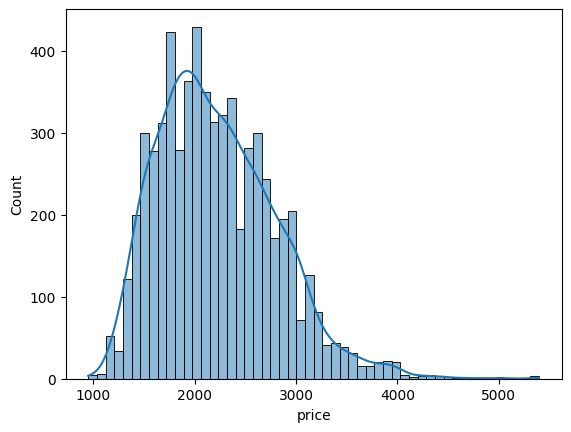

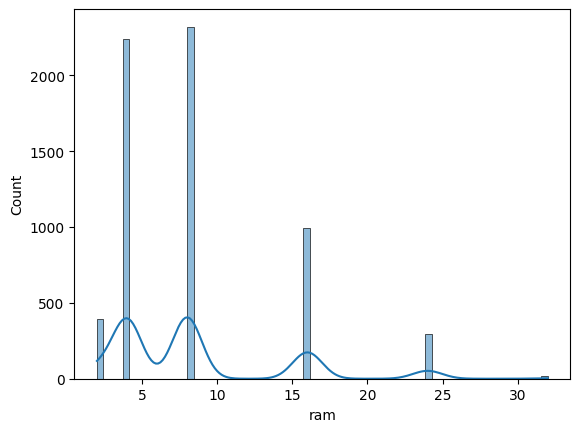

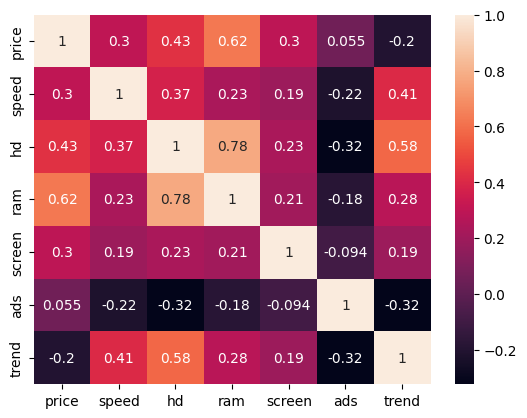

In [8]:
sns.histplot(computers["price"], kde=True)
plt.show()

sns.histplot(computers["ram"], kde=True)
plt.show()

sns.heatmap(computers.corr(numeric_only=True), annot=True)
plt.show()


### Model Fitting

In [5]:
X = computers["ram"]
y = computers["price"]

X = sm.add_constant(X)   # pridedame intercept
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     3964.
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:05:04   Log-Likelihood:                -47180.
No. Observations:                6259   AIC:                         9.436e+04
Df Residuals:                    6257   BIC:                         9.438e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1687.2925     10.221    165.073      0.000    1667.255    1707.330
ram           64.2316      1.020     62.959      0.000      62.232      66.232
==============================================================================
Omnibus:                     1327.783   Durbin-Watson:                   1.533
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3113.140
Skew:                           1.188   Prob(JB):                         0.00
Kurtosis:                       5.508   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Intepretation:


In [ ]:
price= 687.29 + 64.23⋅ram

### Plot Residuals

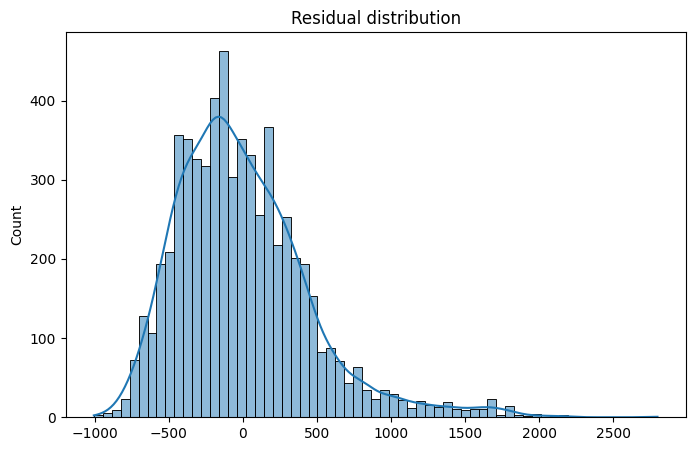

In [10]:
residuals = model.resid

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual distribution")
plt.show()


### Make Predictions with the values below

In [11]:
new_ram = pd.DataFrame({"ram": [0, 2, 4, 8, 16, 32, 64]})
new_ram = sm.add_constant(new_ram)

predictions = model.predict(new_ram)
predictions


0    1687.292537
1    1815.755790
2    1944.219043
3    2201.145550
4    2714.998564
5    3742.704591
6    5798.116644
dtype: float64